# Objectif du notebook 

Date de création : 11/02/2026

À compléter 


In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.spatial.distance import cdist
from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

rtf_mfp_img_folder = os.path.join(img_folder, "rtf_mfp", "library_active_trailed_event_passive")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)

In [4]:
# # Load wav data and plot the corresponding sequence
# ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

# t_start = datetime(year=2025, month=10, day=14, hour=1, minute=15, second=00)
# t_end = datetime(year=2025, month=10, day=14, hour=2, minute=00, second=00)
# # Paramètre STFT
# nperseg = 2**12
# noverlap = 2**11

# fig, axs = plt.subplots(3, 1, sharex=True, figsize=(16, 12))
# axs = np.atleast_1d(axs)

# for i, obs_id in enumerate([1, 2, 3]):

#     datetime_fmt = ds_wav.attrs["datetime_format"]

#     sig_varname = f"signal_obs{obs_id}"
#     time_coordsname = f"time{obs_id}"
#     signal = ds_wav[sig_varname]

#     # Select a window of the signal
#     fs = ds_wav.attrs[f"fs_obs{obs_id}"]

#     # Start of recording
#     t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
#     t0 = datetime.strptime(t0, datetime_fmt)

#     # Select window
#     t_from_t0_start_s = (t_start - t0).total_seconds()
#     n_start = int(t_from_t0_start_s * fs)
#     t_from_t0_end_s = (t_end - t0).total_seconds()
#     n_end = int(t_from_t0_end_s * fs)

#     # Slice signal
#     sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

#     # Define datetime borders
#     t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
#     t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

#     # Derive stft
#     ff, tt, stft = sp.stft(
#         sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
#         fs=fs,
#         window="hann",
#         nperseg=nperseg,
#         noverlap=noverlap,
#         scaling="psd",  # U^2 / Hz
#     )
#     sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
#     # Associated datetime vector
#     tt_datetime = pd.date_range(
#         t0_slice,
#         t0_slice + timedelta(seconds=tt[-1]),
#         freq=f"{tt[1]-tt[0]}s",
#         inclusive="both",
#     )

#     # Plot
#     cmap = "magma"
#     # vmin = np.percentile(sxx, 10)
#     # vmax = np.percentile(sxx, 99)
#     vmin = 25
#     vmax = 45

#     im = axs[i].pcolormesh(tt_datetime, ff, sxx, cmap=cmap, vmin=vmin, vmax=vmax)

#     clabel = r"dB re 1$\mu$Pa$^2$ / Hz"
#     divider = make_axes_locatable(axs[i])
#     cax = divider.append_axes("right", size="2%", pad=0.10)
#     fig.colorbar(im, cax=cax, orientation="vertical", label=clabel)

#     # axs[ich].colorbar(im, label=clabel)

#     axs[i].set_title(f"OBS{obs_id}")

# formatter = mdates.DateFormatter("%H:%M:%S")
# axs[-1].xaxis.set_major_formatter(formatter)
# formatter = mdates.DateFormatter("%H:%M:%S")
# axs[-1].xaxis.set_major_formatter(formatter)
# locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
# axs[-1].xaxis.set_major_locator(locator)
# plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")


# # nticks = 10
# # xmin, xmax = axs[-1].get_xlim()
# # axs[-1].set_xticks(np.linspace(xmin, xmax, nticks))
# # plt.setp(axs[-1].get_xticklabels(), rotation=25, ha="center")

# fig.supylabel("Fréquence [Hz]")
# fig.supxlabel("Temps UTC")
# # fig.suptitle(f"OBS{obs_id}")

# # fpath = os.path.join(root_fig, "spectro_3obs.png")
# # plt.savefig(fpath, bbox_inches="tight")

In [5]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 1
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": BandFilter(order=4, lowcut=100, highcut=900),
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

fsm_props = {
    "fs": 2000,
    "tau_rtf_analysis": 2.0,
    "alpha_overlap": 0.9,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

In [6]:
rtf_mfp_processor.fsm_passive.cm.nperseg

4096

In [7]:
rtf_mfp_processor.fsm_nperseg

4096


Deriving features for active source...

RTF processing of sequences [144] (nb of sequences = 1)
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
RTF feature estimation for sequence 144
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
Deriving replicas for passive source...
A library dataset with ID 6 already exists in C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library. This library dataset will be overwritten.
Dataset (library) saved at C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_6.nc.

Deriving features for active source...

RTF processing of sequences [144] (nb of sequences = 1)
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
RTF feature estimation for sequence 144
Progress: ████████

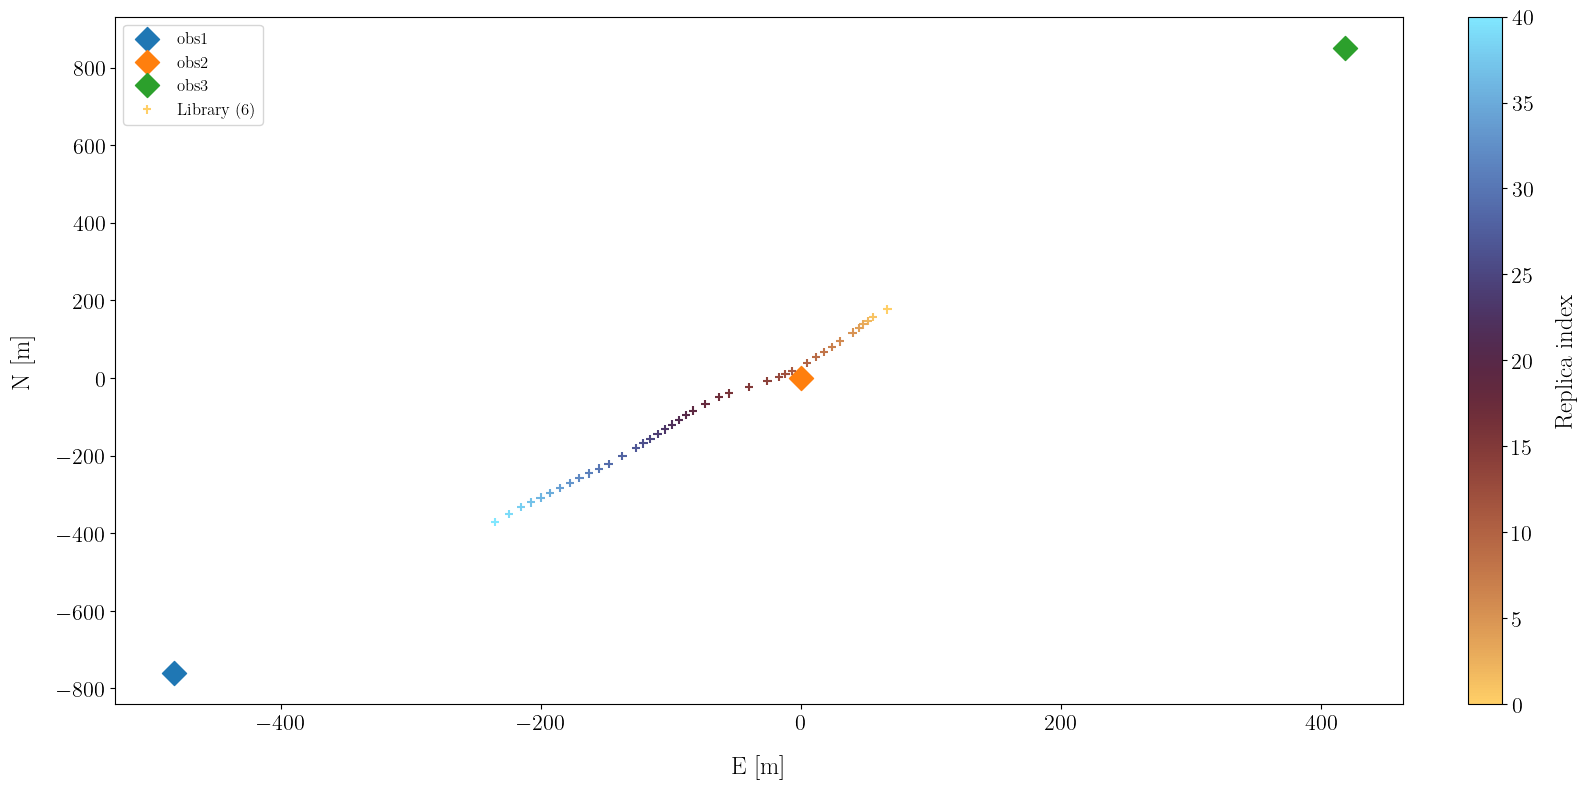

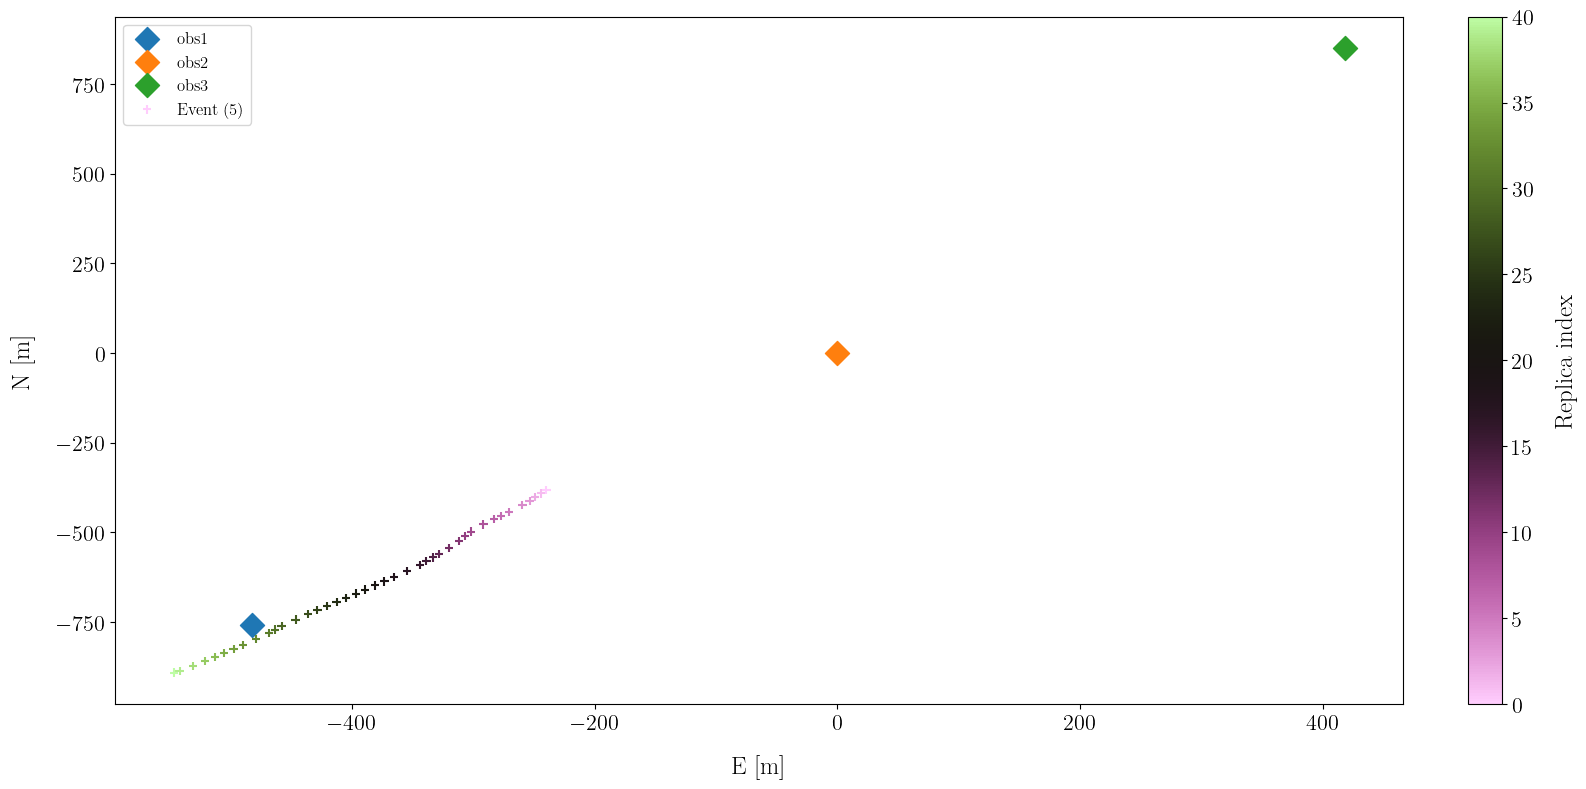

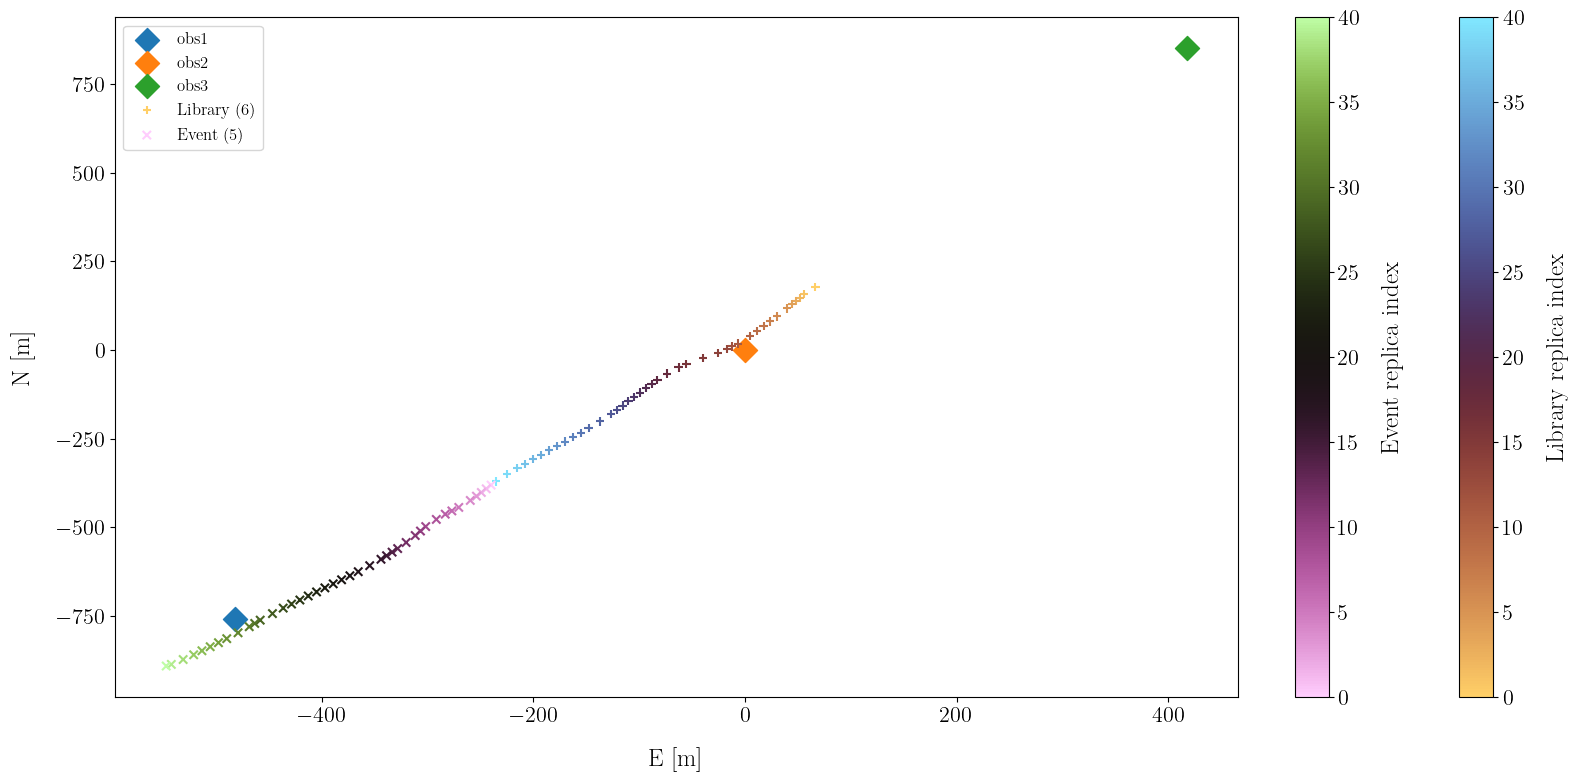

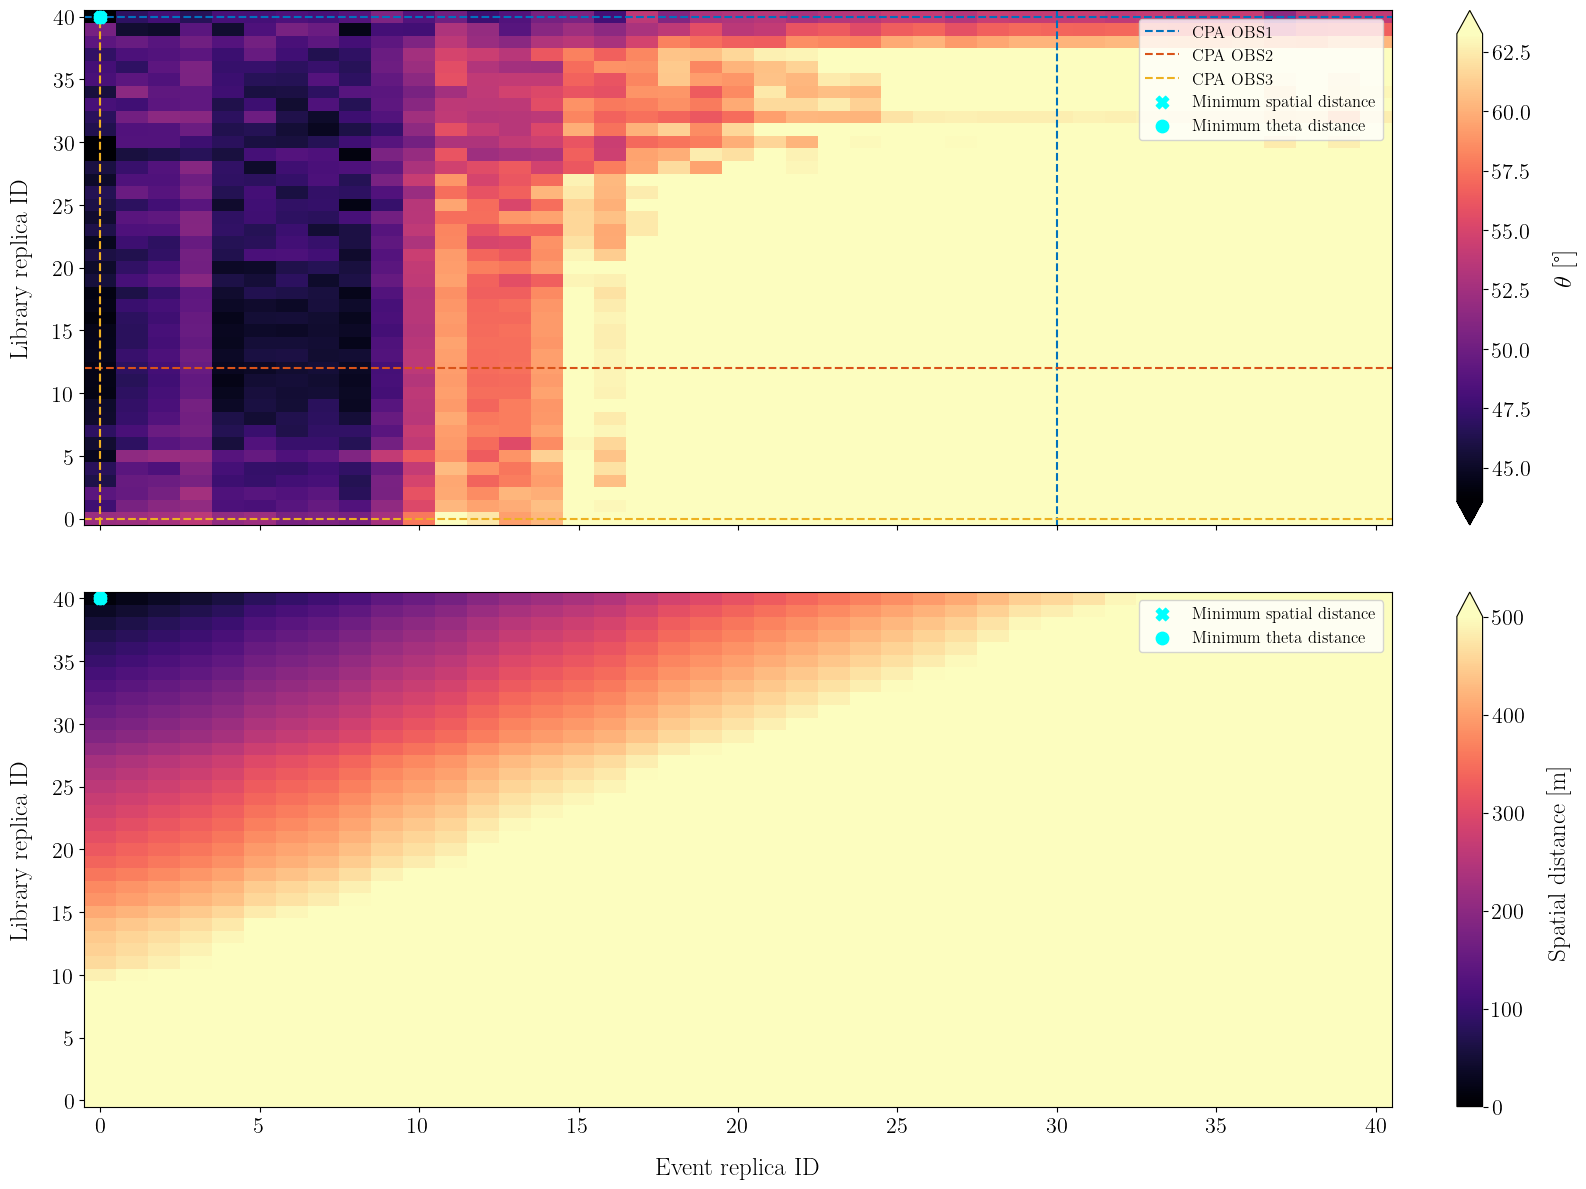

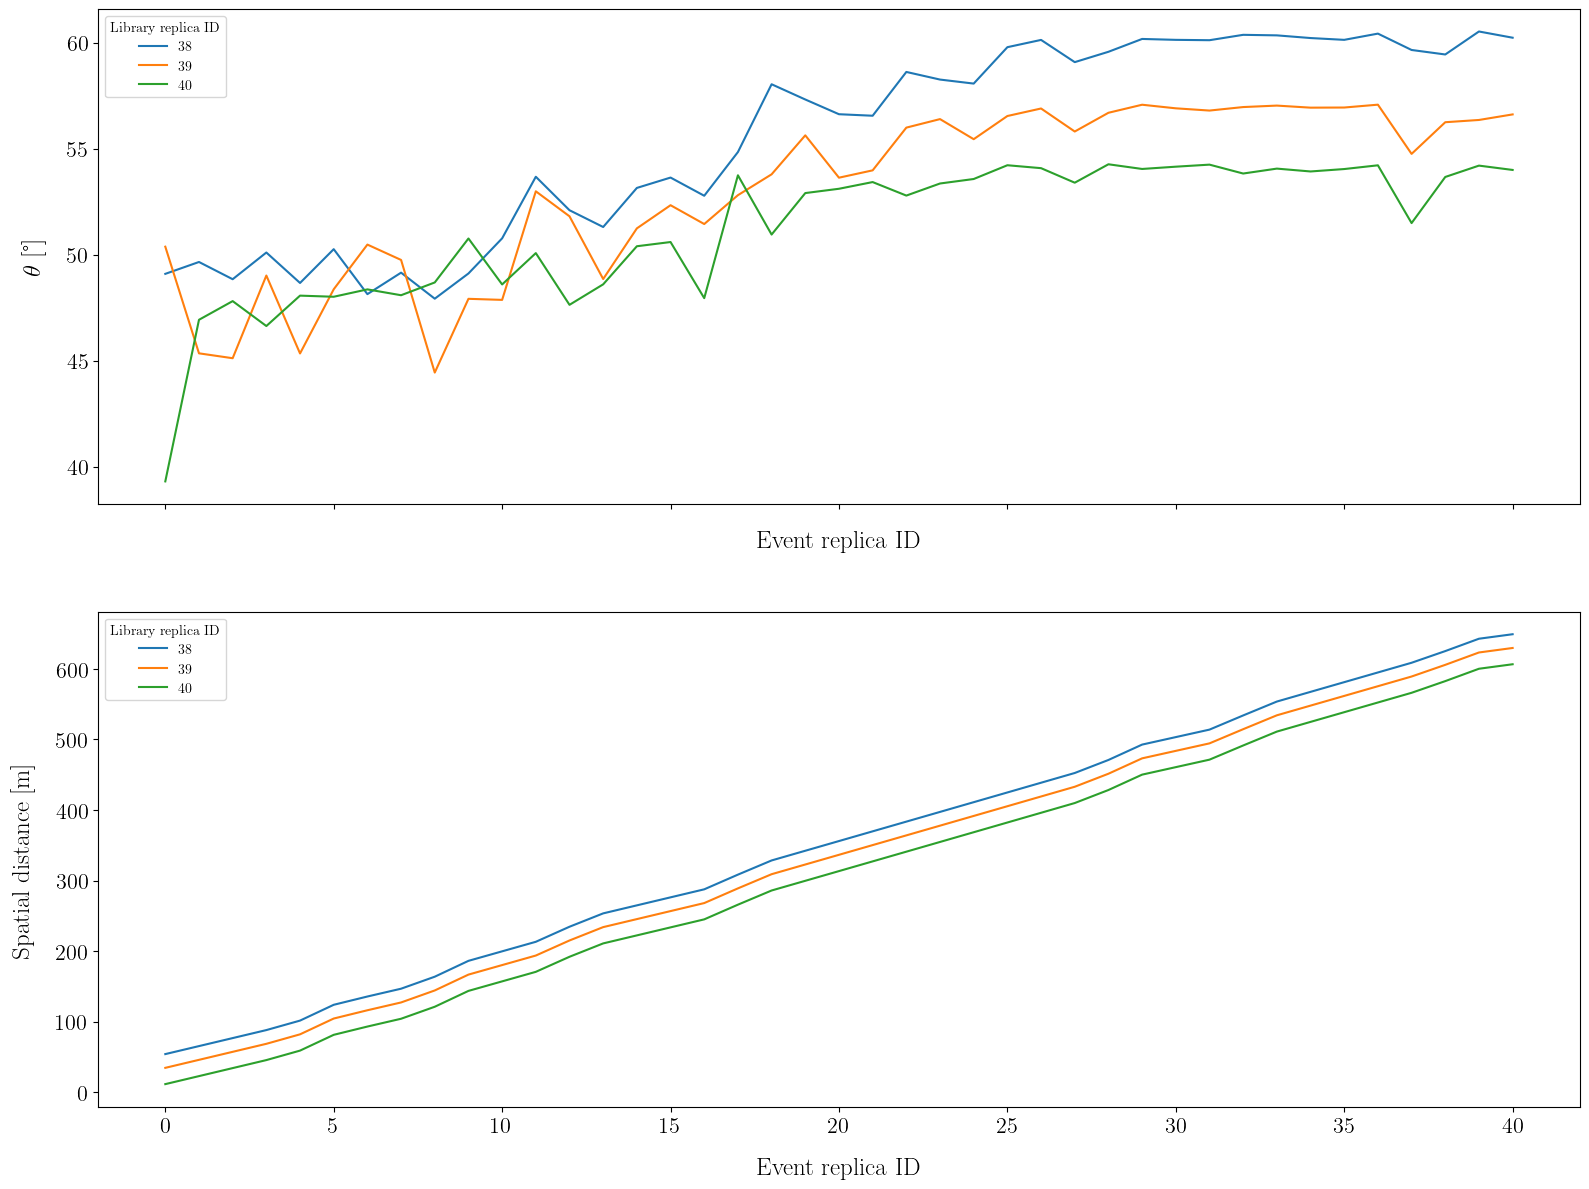

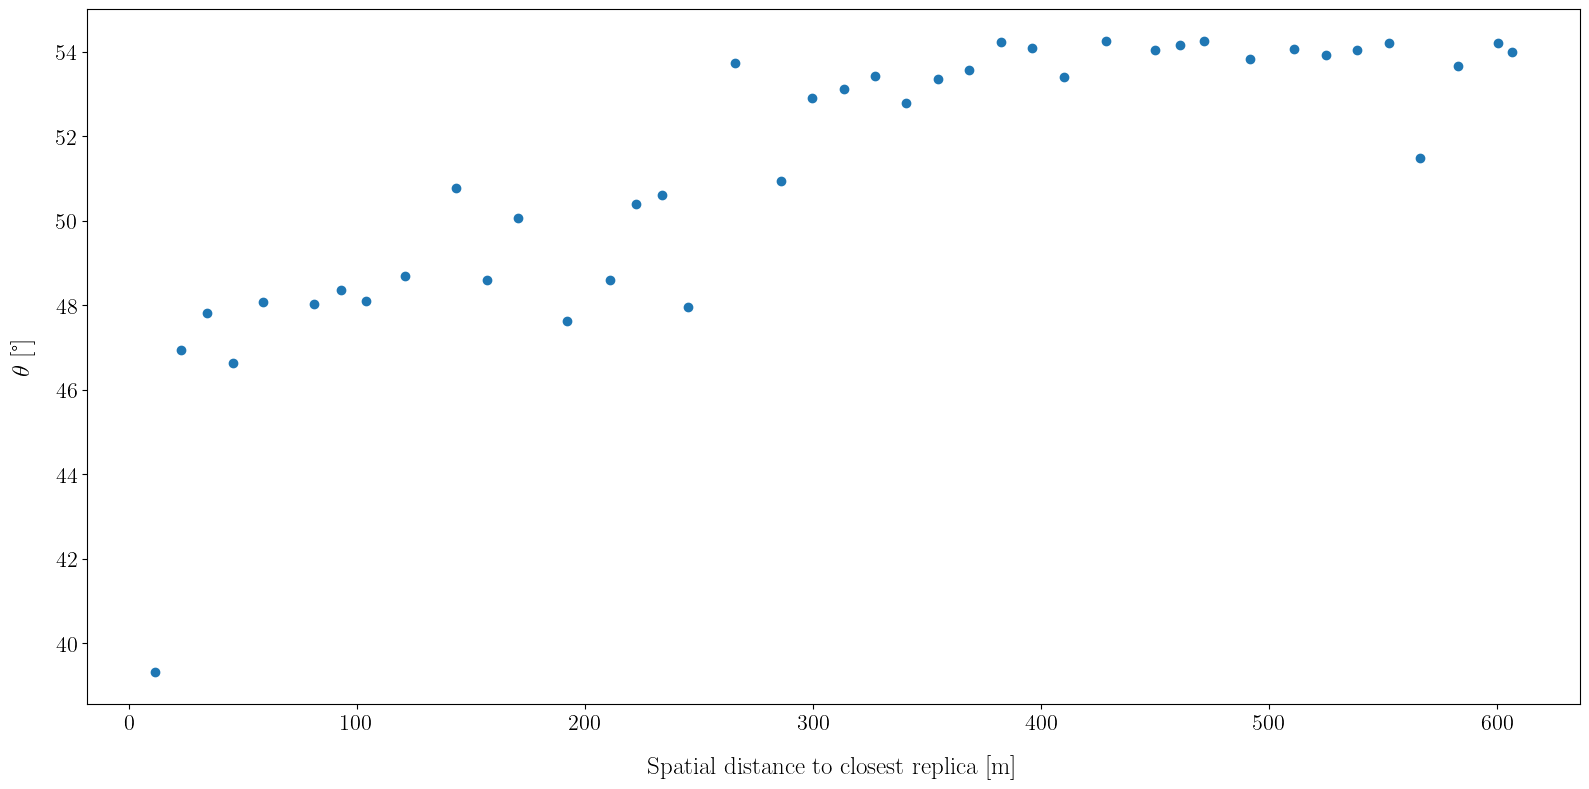

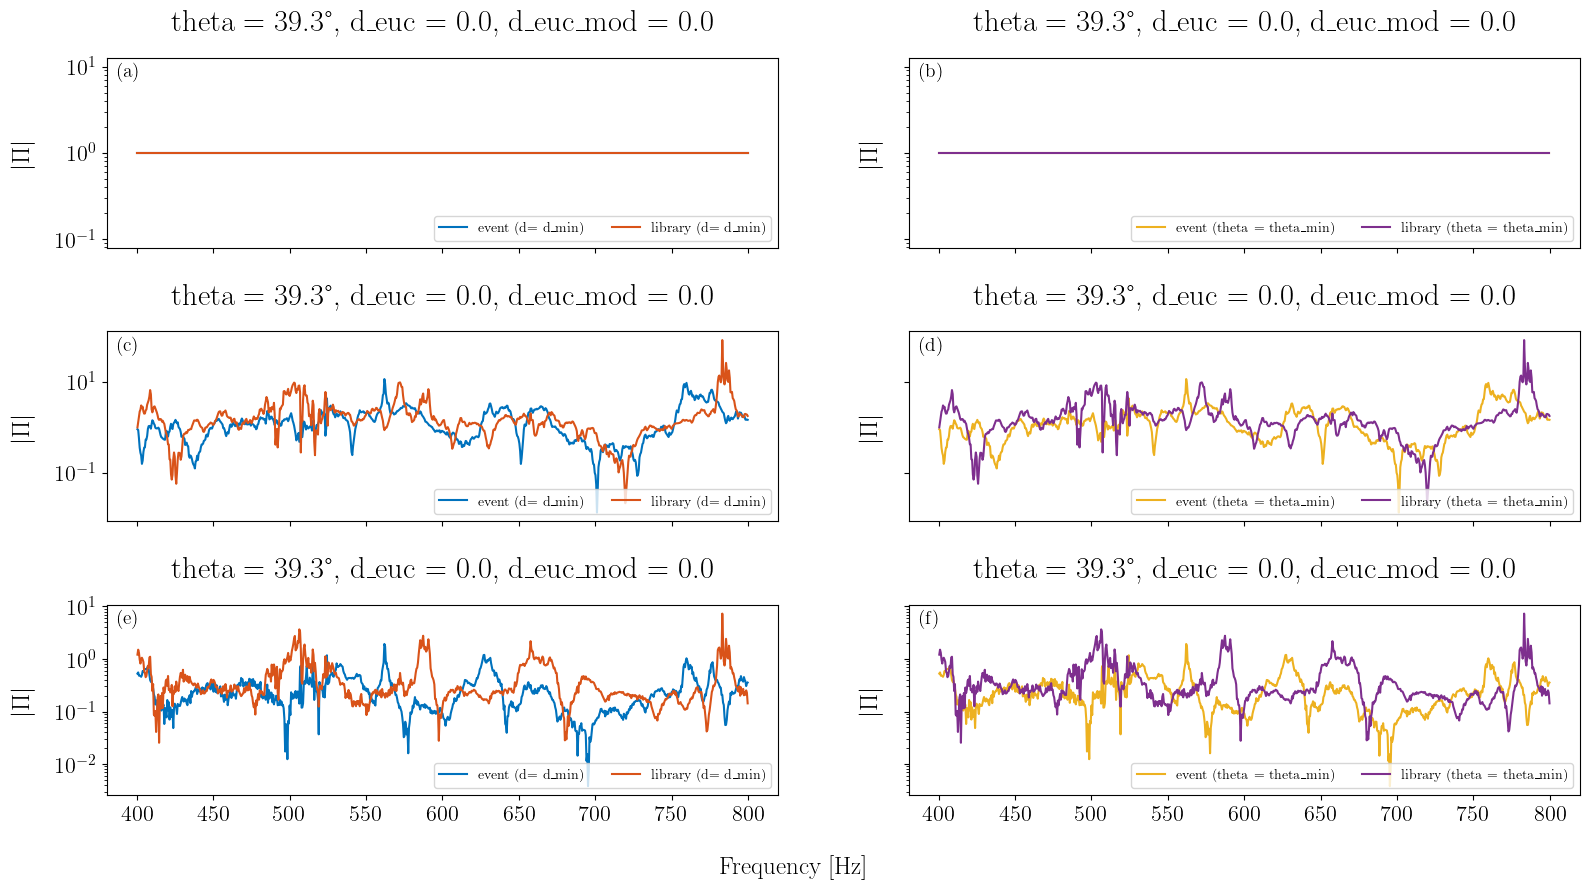

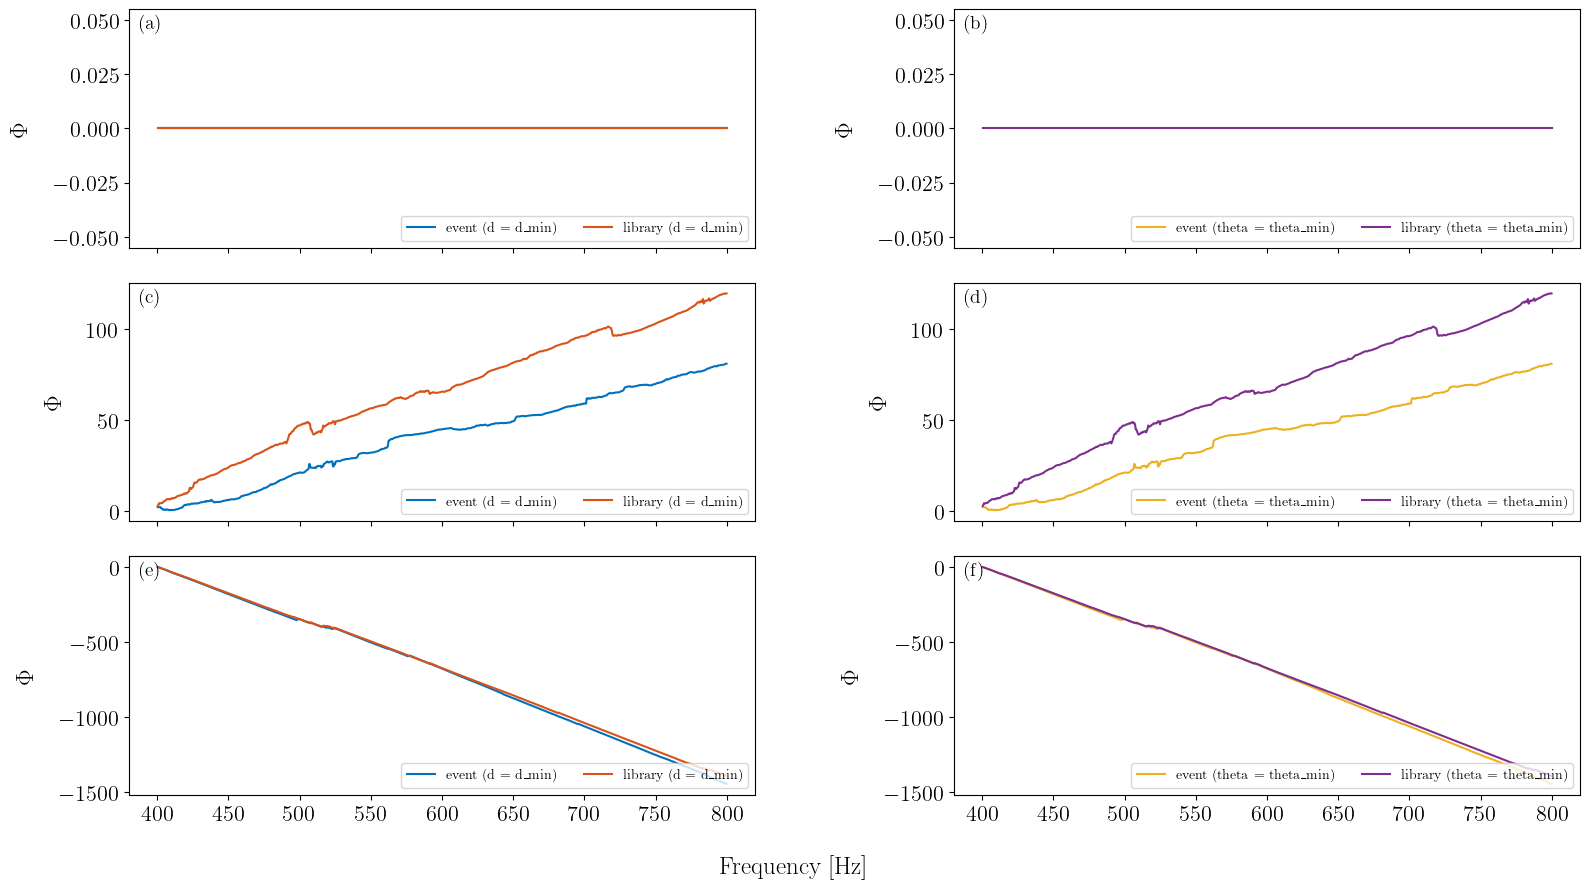

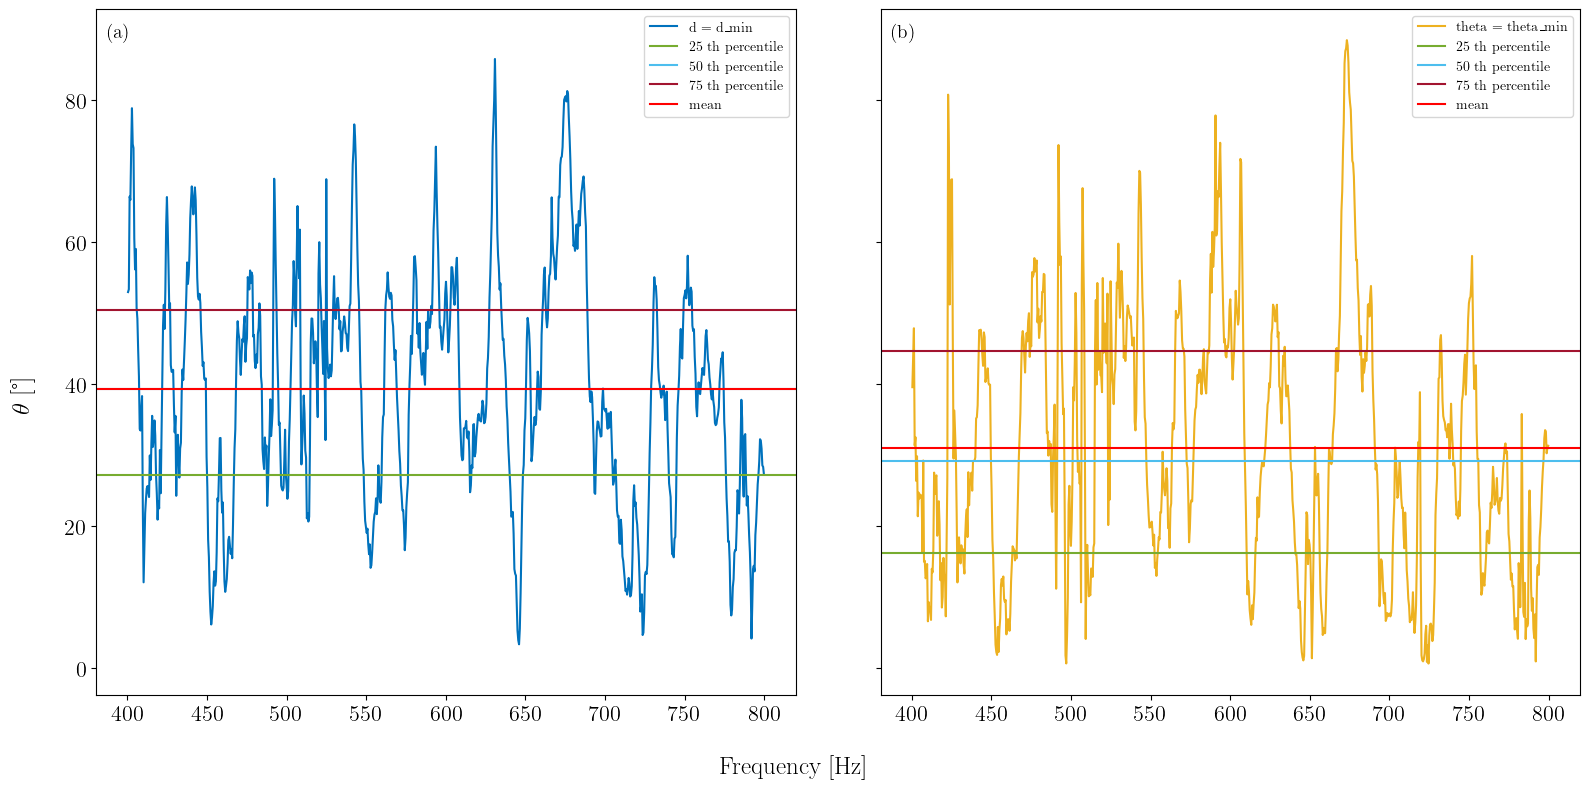

In [8]:
###########################
# Library computation
###########################
id_event = 5
id_library = 6

active_replicas_args = {
    "replica_sequence_ids": [144],
    # "replica_pulse_slice": [(35, 75)],
    "replica_pulse_slice": [(100, 140)],
    "load_precomputed_feature": False,
}

passive_replicas_args = {
    "start_datetimes": [
        # datetime(year=2025, month=10, day=14, hour=1, minute=40, second=00),  # OK lib 2, 3, 4,5
        # datetime(year=2025, month=10, day=15, hour=00, minute=12, second=00),  # OK
    ],
    "end_datetimes": [
        # datetime(
        #     year=2025, month=10, day=14, hour=1, minute=50, second=00
        # ),  # OK lib 2, 3, 4,5
        # datetime(year=2025, month=10, day=15, hour=00, minute=25, second=00),  # OK
    ],
    "load_precomputed_feature": True,
}

rtf_mfp_processor.compute_library(
    active_feature_args=active_replicas_args,
    passive_feature_args=passive_replicas_args,
    id=id_library,
    # Rv_global=Rv_library,
)

###########################
# Event computation
###########################

# Derive event
active_feature_args = {
    "replica_sequence_ids": [144],
    # "replica_pulse_slice": [(76, 115)],
    "replica_pulse_slice": [(141, 181)],
    "load_precomputed_feature": False,
}

target_mmsi = None
passive_feature_args = {
    "start_datetimes": [
        # datetime(year=2025, month=10, day=14, hour=16, minute=40, second=00),
        # datetime(year=2025, month=10, day=14, hour=16, minute=44, second=00),
        # datetime(year=2025, month=10, day=14, hour=2, minute=10, second=00),  # OK
    ],
    "end_datetimes": [
        # datetime(year=2025, month=10, day=14, hour=16, minute=50, second=00),
        # datetime(year=2025, month=10, day=14, hour=16, minute=48, second=00),
        # datetime(year=2025, month=10, day=14, hour=2, minute=20, second=00),  # OK
    ],
    "load_precomputed_feature": False,
}

rtf_mfp_processor.compute_event(
    active_feature_args=active_feature_args,
    passive_feature_args=passive_feature_args,
    id=id_event,
    target_mmsi=target_mmsi,
    # Rv_global=Rv_event,
)

###########################
# Matching library and event features
###########################

dist_args = {
    "fmin": 400,
    "fmax": 800,
    # "dist_type": "hermitian_angle",
    "dist_type": "hermitian_angle_real",
    "use_weighted_mean": False,
}
rtf_mfp_processor.match(id_library=id_library, id_event=id_event, dist_args=dist_args)

In [9]:
rtf_mfp_processor.fsm_passive.cm.nperseg

4096

In [10]:
def get_bootstrap_dist(ds, test_replica_id):
    # Select one replica_id to compare using bootstrap
    test_replica = ds.sel(replica_id=test_replica_id)
    # Remove from the rest of the features for bootstraping
    # bootstrap_replica = ds.drop_sel(replica_id=test_replica_id)
    bootstrap_replica = ds

    # Test RTF
    test_replica_rtf = test_replica.rtf_amp * np.exp(1j * test_replica.rtf_phase)

    # Other RTFs
    bootstrap_replica_rtfs = bootstrap_replica.rtf_amp * np.exp(
        1j * bootstrap_replica.rtf_phase
    )

    # Reshape to 4D array to be able to apply distance function : (n_rcv, n_freq, n_segment_dt) -> (n_rcv, n_freq, n_segment_dt, 1)
    bootstrap_replica_rtfs = bootstrap_replica_rtfs.values[..., np.newaxis]

    # Compute dist
    dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
    # dist = D_hermitian_angle_fast(
    #     rtf_ref=test_replica_rtf.values,
    #     rtf=bootstrap_replica_rtfs,
    #     **dist_kwargs,
    # )

    rtf_ref = np.abs(test_replica_rtf.values)
    rtf = np.abs(bootstrap_replica_rtfs)
    dist = D_hermitian_angle_fast(
        rtf_ref=rtf_ref,
        rtf=rtf,
        **dist_kwargs,
    )

    # # EUCLIDEAN distance
    # d_rcv_1 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=1).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[0, ...]), axis=0
    # )
    # d_rcv_2 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=2).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[1, ...]),
    #     axis=0,
    # )
    # d_rcv_3 = np.linalg.norm(
    #     np.abs(test_replica_rtf.sel(h_index=3).values)[:, np.newaxis]
    #     - np.abs(bootstrap_replica_rtfs[2, ...]),
    #     axis=0,
    # )
    # dist = 1 / 3 * (d_rcv_1 + d_rcv_2 + d_rcv_3)

    # # # Compute dist
    # dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
    # dist = D_euclidian(
    #     rtf_ref=np.abs(test_replica_rtf.isel(h_index=slice(0, 1)).values),
    #     rtf=np.abs(bootstrap_replica_rtfs[0:1, ...]),
    #     **dist_kwargs,
    # )

    # # Expand rtf_ref along the necessary axes for broadcasting
    # rtf_ref_expanded = cast_matrix_to_target_shape(rtf_ref, rtf.shape)

    # # Calculate euclidian distance
    # # d_euc = np.sqrt(np.sum(np.abs(rtf_ref_expanded - rtf) ** 2, axis=1))
    # dist = np.linalg.norm(rtf_ref_expanded - rtf, axis=1)

    return dist 

In [11]:
def get_bootstrap_dist_matrix(ds):
    dist_mat = []
    for i, id in enumerate(ds.replica_id.values): 
        dist_id = get_bootstrap_dist(ds=ds, test_replica_id=id)
        # dist_id = np.concatenate([dist_id[0:i], np.array([0]), dist_id[i:]])       # Add 0 on diagonal 
        dist_mat.append(dist_id)

    dist_mat = np.array(dist_mat)
    return dist_mat

In [12]:
def get_dist_to_rcv(ds):
    e = ds["e_replica"].values
    n = ds["n_replica"].values

    rep_pos = np.column_stack((e, n))
    dist_to_rcv = []
    for i_rcv in ds.h_index.values:
        e_rcv = ds.attrs[f"obs{i_rcv}_e_apriori"]
        n_rcv = ds.attrs[f"obs{i_rcv}_n_apriori"]
        rcv_pos = np.column_stack((e_rcv, n_rcv))

        spatial_dist = cdist(rep_pos, rcv_pos, metric="euclidean")
        dist_to_rcv.append(spatial_dist)

    return np.array(dist_to_rcv)


In [13]:
# id_event = 0
# id_library = 0
root_img = os.path.join(
    rtf_mfp_processor.root_results_fig, f"library_{id_library}_event_{id_event}"
)

In [14]:
# Load event dataset
ds_event = xr.open_dataset(
    os.path.join(rtf_mfp_processor.root_event_data, f"event_{id_event}.nc")
)

# Select frequency band
fmin = 500
fmax = 800
ds_event = ds_event.sel(f_rtf=slice(fmin, fmax))

theta_mat = get_bootstrap_dist_matrix(ds=ds_event)

In [15]:
dist_rcv = get_dist_to_rcv(ds=ds_event)

Text(0.5, 0, 'Replica index')

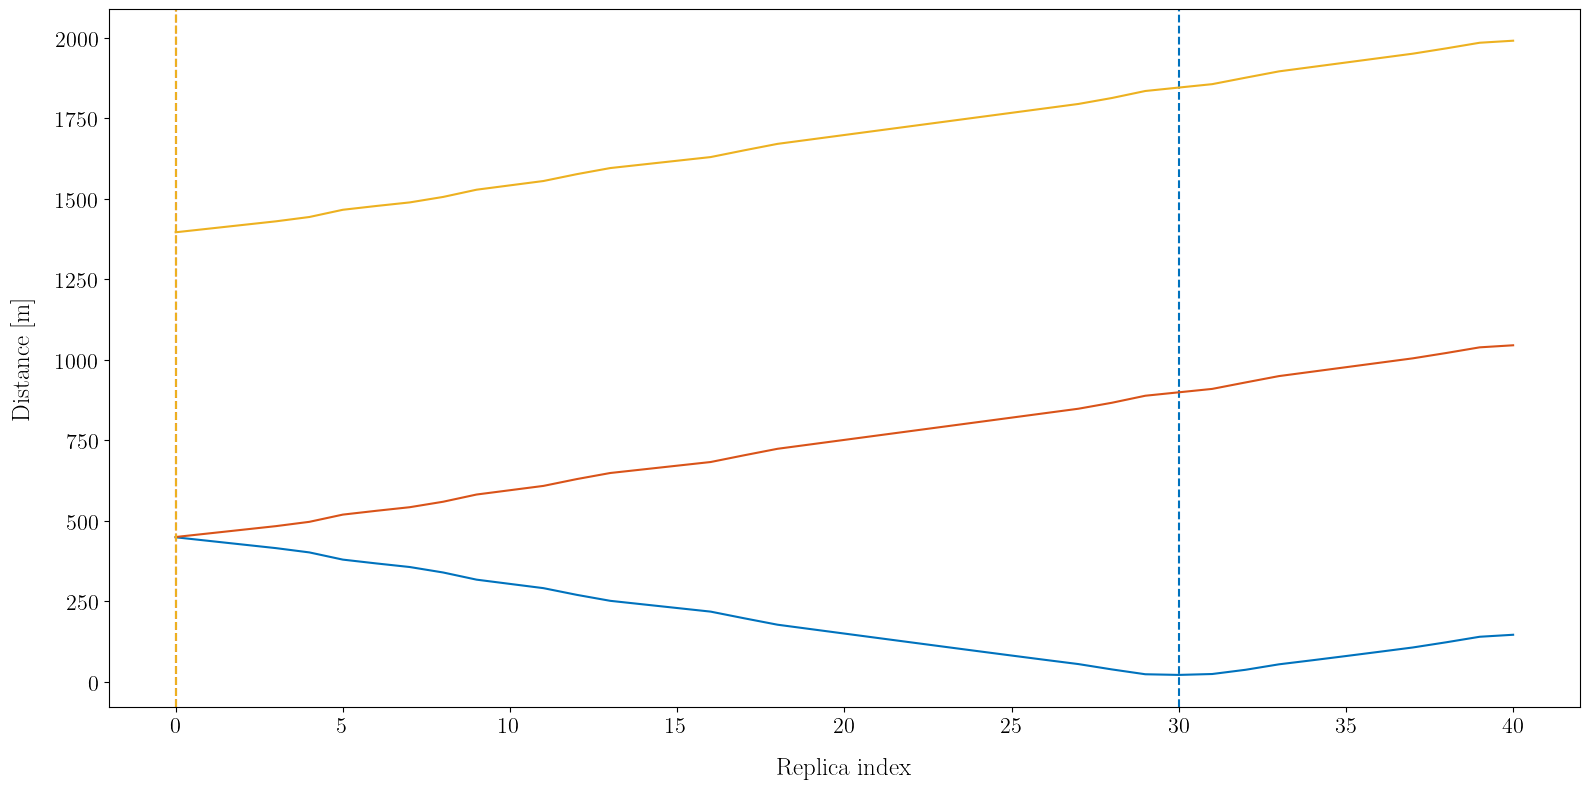

In [16]:
plt.figure()
cpa_idx = []
for i, i_rcv in enumerate(ds_event.h_index.values):
    plt.plot(dist_rcv[i, :], label=f"OBS{i_rcv}", color=color(i))

    cpa_rcv_idx = np.argmin(dist_rcv[i, :])
    plt.axvline(cpa_rcv_idx, linestyle="--", color=color(i))
    cpa_idx.append(cpa_rcv_idx)
    
plt.ylabel(f"Distance [m]")
plt.xlabel("Replica index")

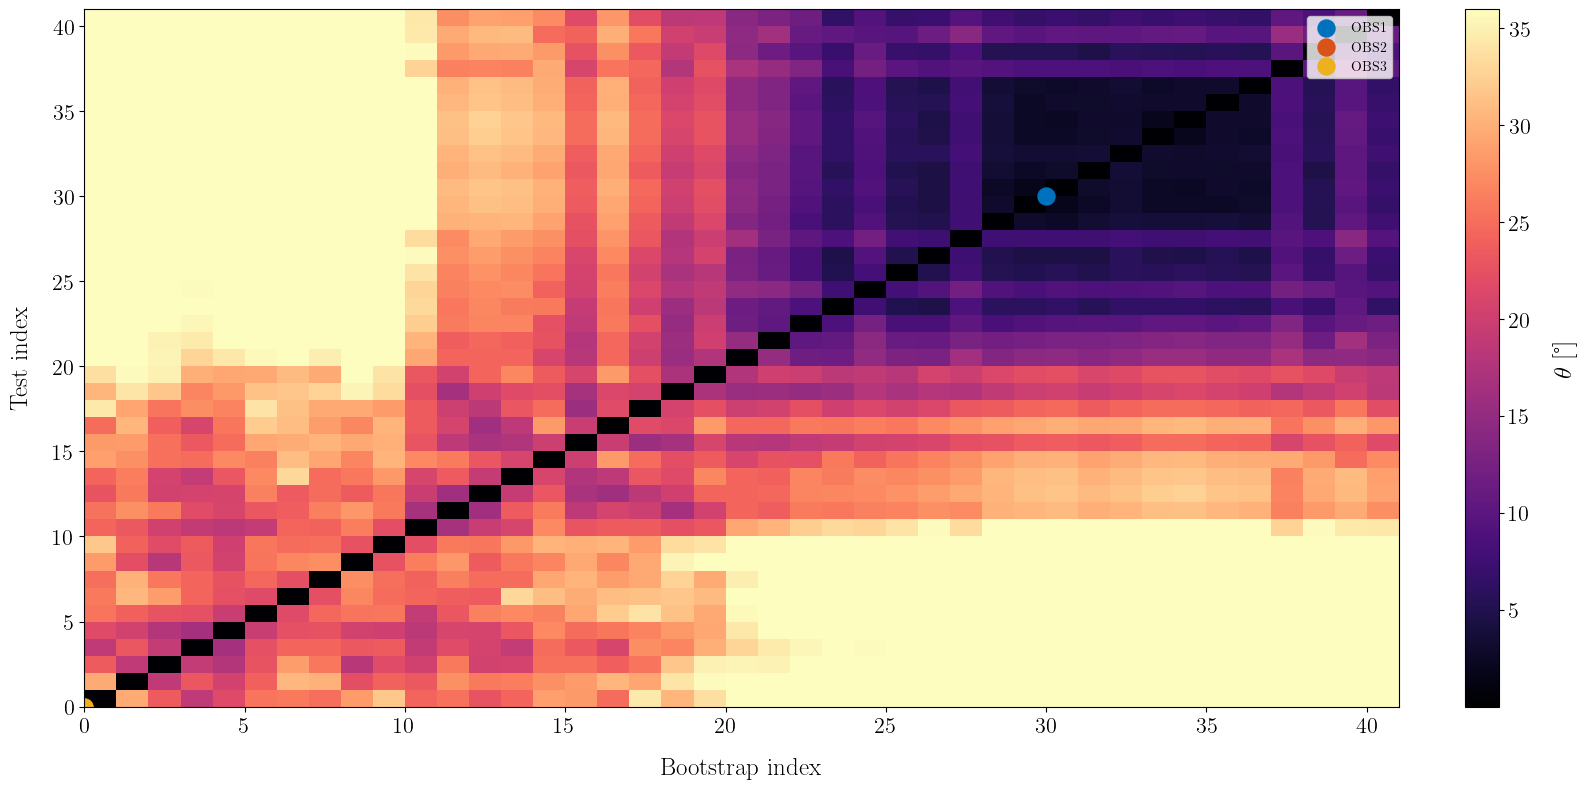

In [17]:
vmax = np.nanpercentile(theta_mat, 75)

plt.figure()
im = plt.pcolormesh(theta_mat, cmap="magma", vmax=vmax)
plt.colorbar(im, label=r"$\theta$ [°]")

# Add CPA indication
for i, i_rcv in enumerate(ds_event.h_index.values):
    plt.scatter(
        cpa_idx[i], cpa_idx[i], marker="o", s=150, color=color(i), label=f"OBS{i_rcv}"
    )
plt.xlabel("Bootstrap index")
plt.ylabel("Test index")
plt.legend()

fpath = os.path.join(
    root_img,
    f"bootstrap_event_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}.png",
)
plt.savefig(fpath)

In [18]:
# Same test with library
ds_library = xr.open_dataset(
    os.path.join(rtf_mfp_processor.root_library_data, f"library_{id_library}.nc")
)
# Select frequency band
# fmin = 400
# fmax = 800
ds_library = ds_library.sel(f_rtf=slice(fmin, fmax))

theta_mat_lib = get_bootstrap_dist_matrix(ds=ds_library)

In [19]:
dist_rcv = get_dist_to_rcv(ds=ds_library)

Text(0.5, 0, 'Replica index')

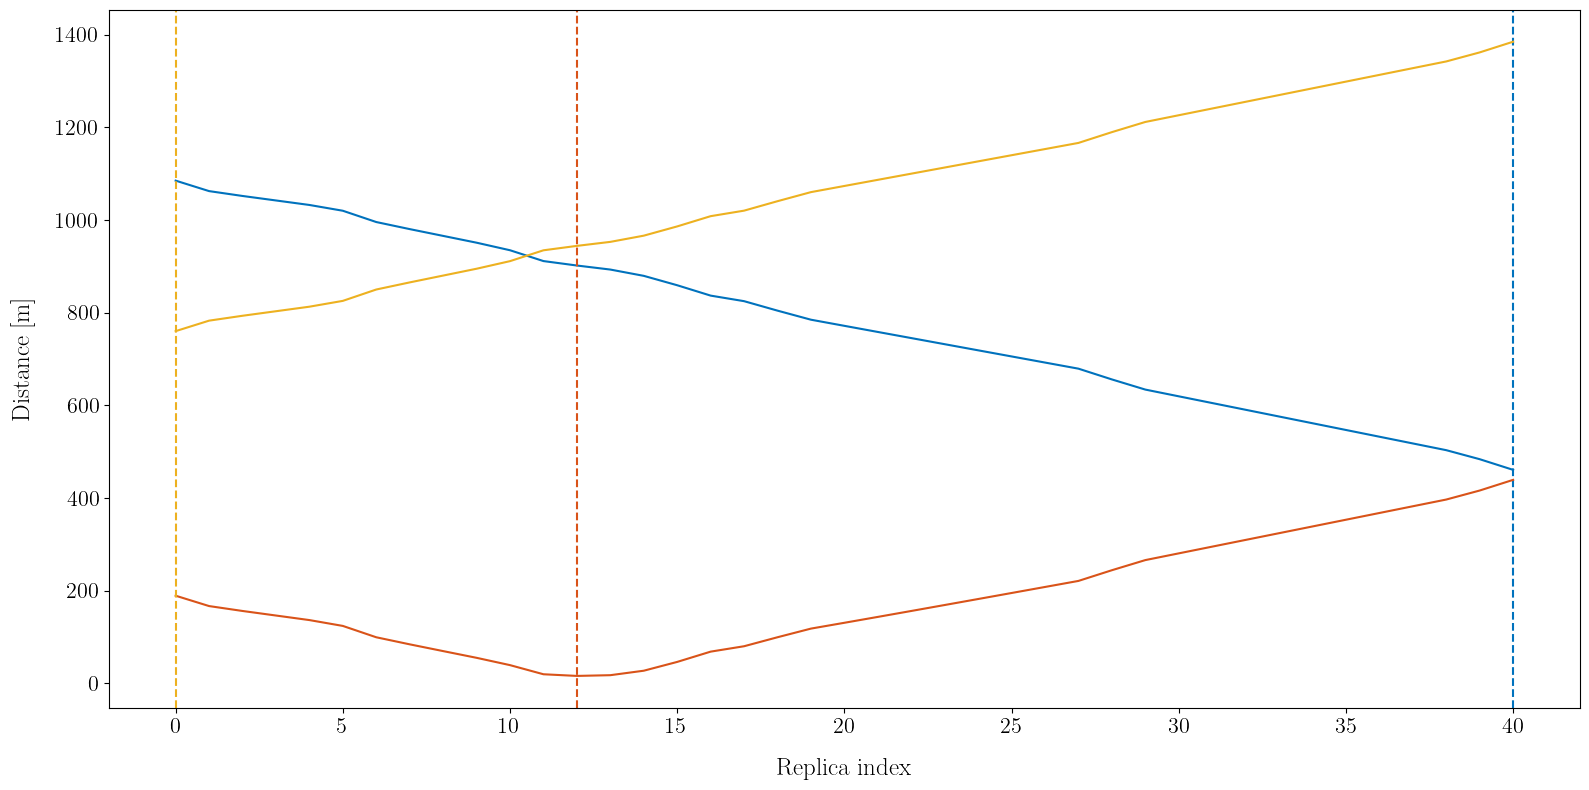

In [20]:
plt.figure()
cpa_idx = []
for i, i_rcv in enumerate(ds_library.h_index.values):
    plt.plot(dist_rcv[i, :], label=f"OBS{i_rcv}", color=color(i))

    cpa_rcv_idx = np.argmin(dist_rcv[i, :])
    plt.axvline(cpa_rcv_idx, linestyle="--", color=color(i))
    cpa_idx.append(cpa_rcv_idx)
    
plt.ylabel(f"Distance [m]")
plt.xlabel("Replica index")

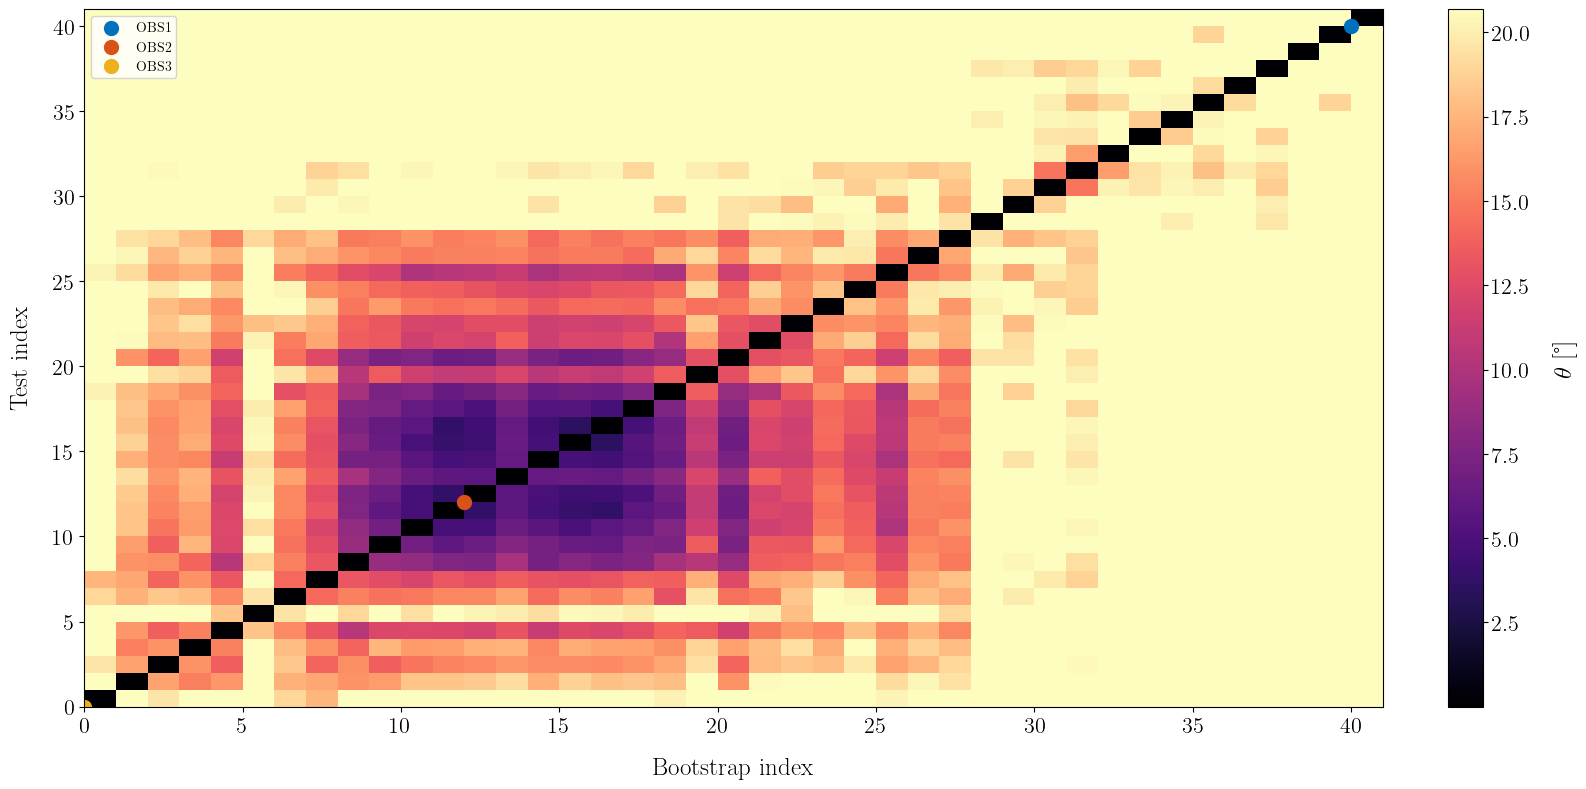

In [21]:
vmax = np.nanpercentile(theta_mat_lib, 50)

plt.figure()
im = plt.pcolormesh(theta_mat_lib, cmap="magma", vmax=vmax)
plt.colorbar(im, label=r"$\theta$ [°]")
# Add CPA indication
for i, i_rcv in enumerate(ds_event.h_index.values):
    plt.scatter(
        cpa_idx[i], cpa_idx[i], marker="o", s=100, color=color(i), label=f"OBS{i_rcv}"
    )
plt.xlabel("Bootstrap index")
plt.ylabel("Test index")
plt.legend()

fpath = os.path.join(
    root_img,
    f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}.png",
)
plt.savefig(fpath)

In [22]:
# # zoom sur la zone du CPA de l'obs 3

# vmax = np.nanpercentile(theta_mat_lib, 10)

# idx_min = 0
# idx_max = 70
# plt.figure()
# im = plt.pcolormesh(
#     theta_mat_lib[idx_min:idx_max, idx_min:idx_max], cmap="magma", vmax=vmax
# )

# plt.colorbar(im, label=r"$\theta$ [°]")
# # Add CPA indication
# plt.scatter(cpa_idx[2], cpa_idx[2], marker="o", s=200, color=color(2), label=f"OBS{3}")
# plt.xlabel("Bootstrap index")
# plt.ylabel("Test index")
# plt.legend(fontsize=18)

# fpath = os.path.join(
#     root_img,
#     f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}_zoomobs3.png",
# )
# plt.savefig(fpath)

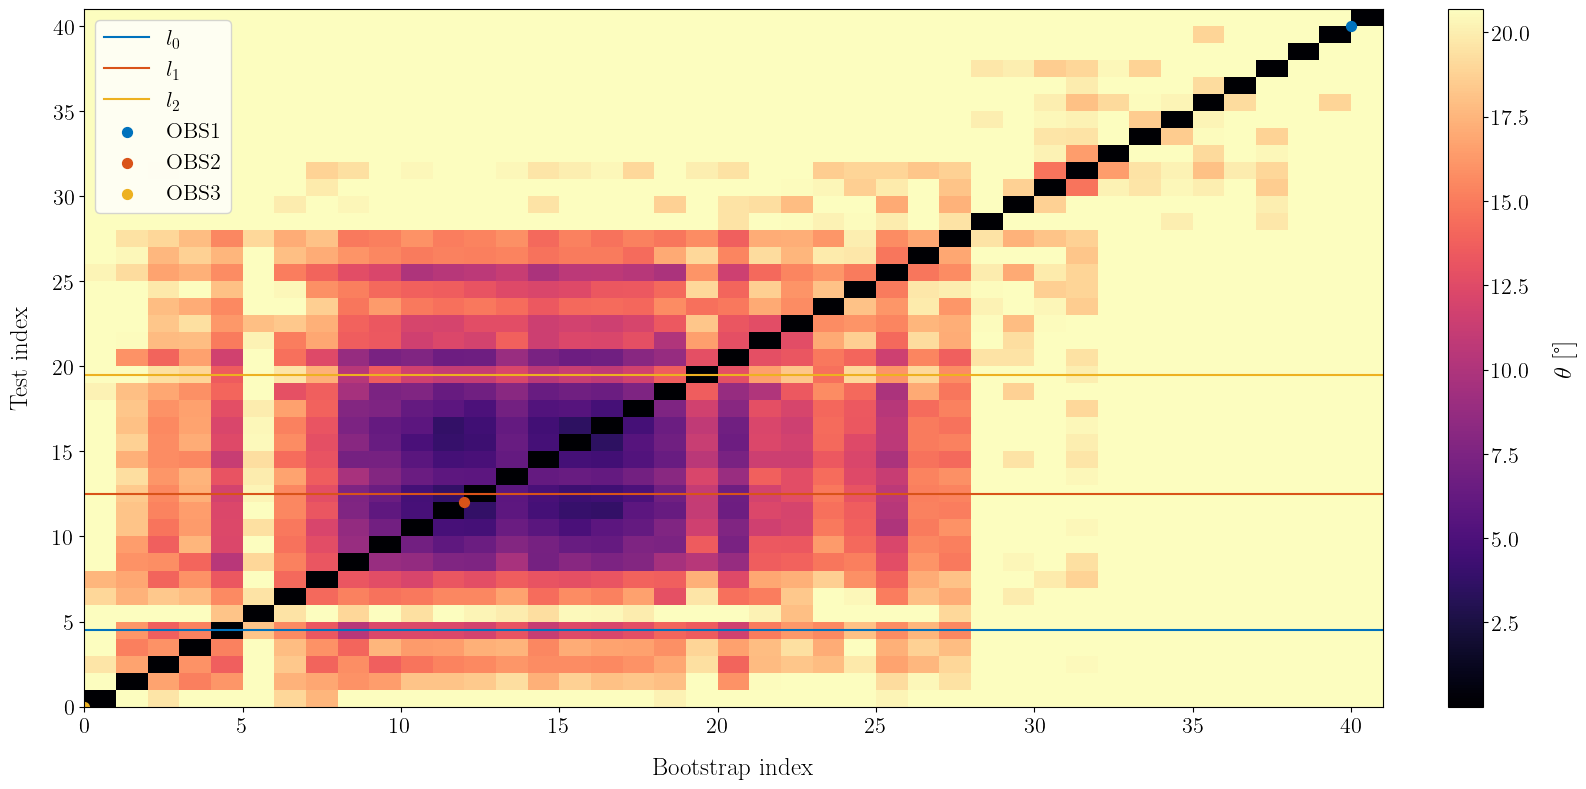

In [26]:
# Quelques lignes à la loupe
# i_1 = 30
# i_2 = 50
# i_3 = 75
# i_4 = 100
# i_5 = 112
# i_6 = 125
# i_7 = 160
# i_8 = 180
# i_ls = [i_1, i_2, i_3, i_4, i_5, i_6, i_7, i_8]


i_ls = [4, 12, 19]

plt.figure()
im = plt.pcolormesh(
    theta_mat_lib, cmap="magma", vmax=vmax
)
for k, i_l in enumerate(i_ls):
    plt.axhline(i_l+0.5, color=color(k), label=rf"$l_{k}$")

plt.colorbar(im, label=r"$\theta$ [°]")
# Add CPA indication
for i, i_rcv in enumerate(ds_event.h_index.values):
    plt.scatter(
        cpa_idx[i], cpa_idx[i], marker="o", s=50, color=color(i), label=f"OBS{i_rcv}"
    )
plt.xlabel("Bootstrap index")
plt.ylabel("Test index")
plt.legend(fontsize=16, loc="upper left")

fpath = os.path.join(
    root_img,
    f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}_zoomobs3_lines.png",
)
plt.savefig(fpath)

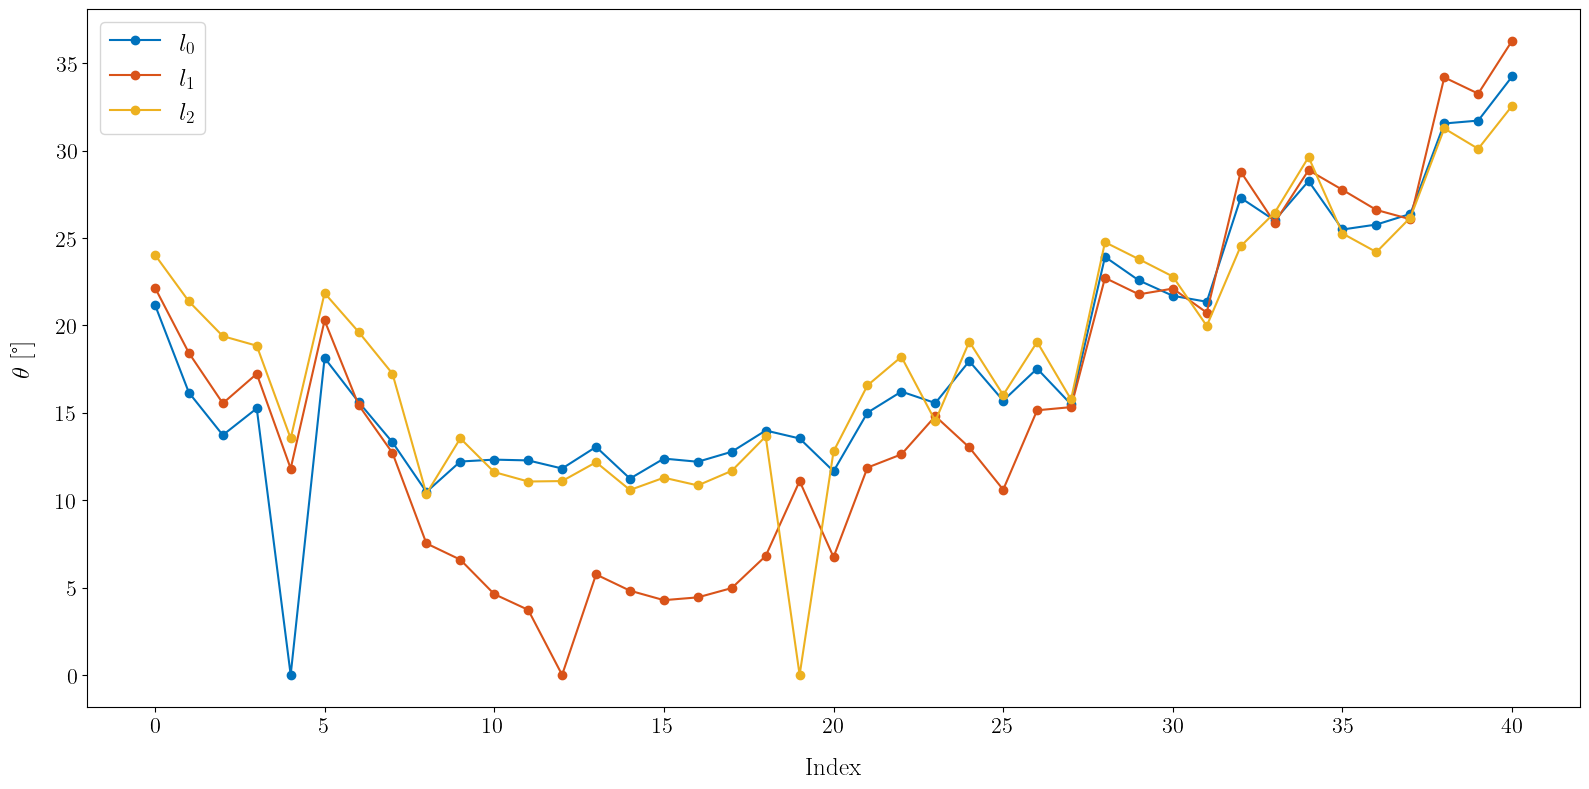

In [27]:
plt.figure()
for k, i_l in enumerate(i_ls):
    plt.plot(theta_mat_lib[i_l, :], marker="o", color=color(k), label=rf"$l_{k}$")

plt.legend(fontsize=18)
plt.xlabel("Index")
plt.ylabel(r"$\theta$ [°]")

fpath = os.path.join(
    root_img,
    f"bootstrap_lib_win{rtf_mfp_processor.fsm_passive_analysis_segment_duration}s_overlap{rtf_mfp_processor.fsm_passive_analysis_segment_alpha_overlap}_zoomobs3_asymetry.png",
)
plt.savefig(fpath)

In [ ]:
i_cpa = 112

n_rcv = ds_library.h_index.size
# Compare module

for i_rcv in range(n_rcv):

    fig, axs = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=(16, 10))
    ax_mod = axs
    h_plot = i_rcv + 1

    # reps = np.arange(i_cpa-10, i_cpa+10, 4)
    # reps = [i_cpa-1, i_cpa, i_cpa+1]
    reps = [39, 40, 46]
    # reps = i_ls
    for ik, i_l in enumerate(reps):

        replica = ds_library.isel(replica_id=i_l)

        # Module
        replica.rtf_amp.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
            ax=ax_mod, label=f"i_l = {i_l}", color=color(ik)
        )

        # ax_mod_dist[i_rcv].set_title(
        #     f"theta = {theta_along_rcv_at_min_spatial_dist:.1f}°, d_euc = {euc_dist_at_min_spatial_dist:.1f}, d_euc_mod = {euc_mod_dist_at_min_spatial_dist:.1f} "
        # )

        # ax_mod_dist[i_rcv].set_ylim([0.01, 100])
        ax_mod.set_yscale("log")
        ax_mod.set_xlabel("")
        ax_mod.set_ylabel(r"$|\Pi|$")
        # ax_mod_dist[i_rcv].set_ylabel("")
        # ax_mod_dist[i_rcv].set_title("")
        ax_mod.legend(fontsize=14, ncol=3, loc="upper right")

        # # ax_mod_rtf_dist[i_rcv].set_ylim([0.01, 100])
        # ax_mod_rtf_dist[i_rcv].set_yscale("log")
        # ax_mod_rtf_dist[i_rcv].set_xlabel("")
        # ax_mod_rtf_dist[i_rcv].set_ylabel(r"$|\Pi|$")
        # # ax_mod_rtf_dist[i_rcv].set_ylabel("")
        # # ax_mod_rtf_dist[i_rcv].set_title("")
        # ax_mod_rtf_dist[i_rcv].legend(fontsize=10, ncol=3, loc="lower right")
        # plt.xlim([450, 550])

set_subfigures_abc_labels(
    axs=axs, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)

fig.supxlabel("Frequency [Hz]")

# if save_fig:
#     fpath = os.path.join(
#         root_img,
#         f"res_library_{ds_results.library_id}_event_{ds_results.event_id}_feature_comparison_mod.png",
#     )
#     plt.savefig(fpath, bbox_inches="tight")

In [ ]:

# h_plot = 3

# ### Compare two adjacent features ###
# rtf_1_mod = min_dist_event.rtf_amp.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax))
# rtf_2_mod = min_dist_p1_event.rtf_amp.sel(h_index=h_plot).sel(
#     f_rtf=slice(fmin, fmax)
# )
# rtf_1_phase = min_dist_event.rtf_phase.sel(h_index=h_plot).sel(
#     f_rtf=slice(fmin, fmax)
# )
# # rtf_2_phase = min_dist_p1_event.rtf_phase.sel(h_index=h_plot).sel(
# #     f_rtf=slice(fmin, fmax)
# # )
# rtf_2_phase = rtf_1_phase

# rtf_1 = rtf_1_mod * np.exp(1j * rtf_1_phase)
# rtf_2 = rtf_2_mod * np.exp(1j * rtf_2_phase)

# euc_dist = np.linalg.norm(rtf_1 - rtf_2)
# euc_mod_dist = np.linalg.norm(rtf_1_mod - rtf_2_mod)
# dist_kwargs = {"ax_rcv": 1, "ax_f": 0, "apply_mean": False, "unit": "deg"}
# theta_along_f = D_hermitian_angle_fast(
#     rtf_ref=np.atleast_2d(rtf_1),
#     rtf=np.atleast_2d(rtf_2),
#     **dist_kwargs,
# )
# # Classical hermitian angle
# rtf_1_mod = min_dist_event.rtf_amp.sel(f_rtf=slice(fmin, fmax))
# rtf_2_mod = min_dist_p1_event.rtf_amp.sel(f_rtf=slice(fmin, fmax))
# rtf_1_phase = min_dist_event.rtf_phase.sel(f_rtf=slice(fmin, fmax))
# rtf_2_phase = min_dist_p1_event.rtf_phase.sel(f_rtf=slice(fmin, fmax))
# rtf_1 = rtf_1_mod * np.exp(1j * rtf_1_phase)
# rtf_2 = rtf_2_mod * np.exp(1j * rtf_2_phase)

# euc_dist = np.linalg.norm(rtf_1 - rtf_2)
# euc_mod_dist = np.linalg.norm(rtf_1_mod - rtf_2_mod)
# dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}
# theta_along_rcv = D_hermitian_angle_fast(
#     rtf_ref=rtf_1.values,
#     rtf=rtf_2.values,
#     **dist_kwargs,
# )

# print(f"Euclidian distance (module) at d = d_min = {euc_mod_dist}")
# print(f"Euclidian distance (in C) at d = d_min = {euc_dist}")
# print(f"Hermitian angle distance along freq (in C) at d = d_min = {theta_along_f}°")
# print(
#     f"Hermitian angle distance along rcv (in C^n_rcv) at d = d_min = {theta_along_rcv}°"
# )